In [39]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import tqdm

# Function to determine probability of switching

In [40]:
def probability_at_time(pc, n_coop_cur, n_coop_pop, n_trials_cur, n_trials_pop, pop_info, T, R, P, S, switching_threshold): # p is probability of current partner coop; n_total is the number of trials
    a = 1
    b = 1

    pc = pc
    switch_fit_multiplier = 1

    # T = 0.8 # D / C
    # R = 0.6 # C / C
    # P = 0.2 # D / D
    # S = 0.4 # C / D

    population_a = a + pop_info * n_coop_pop
    population_b = b + pop_info * (n_trials_pop - n_coop_pop)

    current_a = population_a + n_coop_cur
    current_b = population_b + (n_trials_cur - n_coop_cur)

    samples_current = stats.beta.rvs(current_a, current_b, size=10000)
    samples_population = stats.beta.rvs(population_a, population_b, size=10000)

    staying_fitness =  (
            samples_current * (pc * R + (1 - pc) * T) +
            (1 - samples_current) * (pc * S + (1 - pc) * P)
        )

    switching_fitness =  (
            samples_population * (pc * R + (1 - pc) * T) +
            (1 - samples_population) * (pc * S + (1 - pc) * P)
        )

    payoff_difference = (switching_fitness * switch_fit_multiplier) - staying_fitness
    ps = np.mean(payoff_difference > switching_threshold) # expectation that switching is better than staying

    payoff = ps * (switching_fitness * switch_fit_multiplier) + (1 - ps) * staying_fitness # expected payoff

    return list([np.mean(payoff), ps, samples_current, samples_population, np.std(payoff)])

# Model components

In [41]:
class Population:
    def __init__(self):
        self.animals = []

    def attach_animal(self, animal):
        self.animals.append(animal)
        animal.population = self

    def summary(self):
        return [animal.summary() for animal in self.animals]

class Animal:
    def __init__(self, id, pc):

        # Identity and behaviour
        self.id = id
        self.pc = pc
        self.ps = 0
        self.switching_threshold = 0

        # Data
        self.n_partners = 0
        self.n_partners_switched_from = 0

        # For use in model
        self.payoff = 0
        self.partner = None
        self.n_coop_cur = 0
        self.n_coop_pop = 0
        self.n_trials_cur = 0
        self.n_trials_pop = 0

        self.population = None

        self.T = 0.8 # D / C
        self.R = 0.6 # C / C
        self.P = 0.2 # D / D
        self.S = 0.4 # C / D

        # self.T = 0.2 # D / C # pure coordination game
        # self.R = 0.8 # C / C
        # self.P = 0.8 # D / D
        # self.S = 0.2 # C / D

    def step(self, i):
        # self.n_steps += 1
        if self.partner is None:
            if np.random.uniform(0, 1) < 1: # most of the time individuals find a new partner, but sometimes they remain alone
                self._find_new_partner()
            else:
                payoff = 0.4
                self.payoff = payoff

        if self.partner is not None:
            result = probability_at_time(self.pc, self.n_coop_cur, self.n_coop_pop, self.n_trials_cur, self.n_trials_pop, M, self.T, self.R, self.P, self.S, self.switching_threshold) # probability of switching and payoff

            self.n_coop_cur += round(self.partner.pc, 0) # binarise cooperation -- does current partner cooperate or not?
            self.n_coop_pop += round(self.partner.pc, 0) 
            self.n_trials_cur += 1
            self.n_trials_pop += 1

            prob = result[1] # probability of self switching
            self.ps = result[1]

            if prob > np.random.uniform(0, 1): # with probability prob, find new partner
                self._find_new_partner()
            
            self._calculate_payoff()

    def _calculate_payoff(self):
        payoff = 0
        if round(self.partner.pc, 0) == 1: # if my partner cooperates
            if self.pc > np.random.uniform(0, 1): # I cooperate
                payoff = self.R
                # payoff = 1
            else:
                payoff = self.T
                # payoff = 1
        elif round(self.partner.pc, 0) == 0: # if my partner defects
            if self.pc > np.random.uniform(0, 1):
                payoff = self.S
                # payoff = 0
            else:
                payoff = self.P
                # payoff = 0 
        self.payoff = payoff

    def _find_new_partner(self):
        candidate_partners = self.population.animals.copy()
        candidate_partners.remove(self)
        if self.partner is not None: # if animal has a partner, remove partner
            self.partner.n_partners_switched_from += 1
            candidate_partners.remove(self.partner)
            self.partner.partner = None
            self.partner = None
        for animal in candidate_partners: # if potential partner has a partner, remove potential partner from candidate partners
                if animal.partner is not None:
                    candidate_partners.remove(animal)

        if len(candidate_partners) > 0: # if there are potential partners, choose one
            self.partner = np.random.choice(candidate_partners)
            self.partner.partner = self
            self.n_partners += 1
            self.n_coop_cur = 0
            self.n_trials_cur = 0
        else: # if there are no potential partners, stay alone (there should always be potential partners because there is an even number of individuals)
            self.partner = None
            print("No partners available")

    def reset(self, parent):
        if self.partner != None:
            self.partner.partner = None

        self.partner = None
        self.n_coop_cur = 0
        self.n_coop_pop = 0
        self.n_trials_cur = 0
        self.n_trials_pop = 0
        self.n_partners = 0
        self.n_partners_switched_from = 0
        self.n_steps = 0
        self.ps = 0
        self.switching_threshold = np.clip(parent.switching_threshold + np.random.normal(0, 1), 0, 1)

    def summary(self):
        return {
            'id': self.id,
            'pc': self.pc,
            'partner': self.partner.id if self.partner is not None else None,
            'n_partners': self.n_partners,
            'ps': self.ps
        }
    

# Model run

In [42]:
all_mean_n_partners = []
all_std_n_partners = []
all_uncertainty = []
all_mean_pc = []
all_std_pc = []
all_mean_ps = []
all_pop_pc_dist = []
all_iterations = []
all_mean_payoff = []
all_std_payoff = []
all_mean_partner_pc = []
all_std_partner_pc = []
all_steps = []
all_mean_switched_from = []
all_rsquared_asstmnt = []
all_coef_asstmnt = []
all_rsquared_payoff = []
all_coef_payoff = []
all_switching_threshold = []


pop_info = np.arange(0, 1, 0.1)

all_ids = []
all_switched_from = []
all_mean_pc_indiv = []
all_mean_ps_indiv = []
all_mean_switching_threshold = []

run = []
pop_infos = []
all_mean_partner_pc_indiv = []

a_val = 3
b_val = 3
num_iterations = 50
num_timesteps = 100000
for M in tqdm.tqdm(pop_info):
    for j in np.arange(0, num_iterations):
        population_size = 11
        population = Population()

        for id in range(population_size):
            population.attach_animal(Animal(id, stats.beta.rvs(3, 3, size=1)[0]))

        # ps_df = pd.DataFrame(columns=["animal_id", "ps_val", "pc_val"])
        for i in range(num_timesteps):
            animal = np.random.choice(population.animals)
            animal.step(i)
            if i % 100 == 0:
                contender_1 = np.random.choice(population.animals) 
                contender_2 = np.random.choice(population.animals) 
                while contender_1 == contender_2: # make sure that contender 1 isn't also contender 2
                    contender_2 = np.random.choice(population.animals) 
                if contender_1.payoff > contender_2.payoff:
                    contender_2.reset(contender_1) # reset contender 2, with contender 1 as the parent
                elif contender_2.payoff > contender_1.payoff:
                    contender_1.reset(contender_2) # reset contender 1, with contender 2 as the parent

        mean_n_partners = np.mean([animal.n_partners for animal in population.animals]) # calculate data means for the populations

        run.append([j] * len(population.animals))
        pop_infos.append([M] * len(population.animals))
        all_ids.append([animal.id for animal in population.animals])
        all_switched_from.append([animal.n_partners_switched_from for animal in population.animals])
        all_mean_pc_indiv.append([animal.pc for animal in population.animals])
        all_mean_ps_indiv.append([animal.ps for animal in population.animals])
        all_switching_threshold.append([animal.switching_threshold for animal in population.animals])
        for animal in population.animals:
            if animal.partner is not None:
                all_mean_partner_pc_indiv.append(animal.partner.pc)
            else:
                all_mean_partner_pc_indiv.append('NA')

        mean_n_switched_from = np.mean([animal.n_partners_switched_from for animal in population.animals])
        mean_switching_threshold = np.mean([animal.switching_threshold for animal in population.animals])
        mean_pc = np.mean([animal.pc for animal in population.animals])
        std_pc = np.std([animal.pc for animal in population.animals])
        mean_ps = np.mean([animal.ps for animal in population.animals])
        mean_partner_pc = np.mean([animal.partner.pc for animal in population.animals if animal.partner is not None])
        std_partner_pc = np.std([animal.partner.pc for animal in population.animals if animal.partner is not None])
    
        all_mean_n_partners.append(mean_n_partners) # add data to lists
        all_mean_switched_from.append(mean_n_switched_from)
        all_mean_switching_threshold.append(mean_switching_threshold)
        all_mean_pc.append(mean_pc)
        all_mean_ps.append(mean_ps)
        all_uncertainty.append(M)
        all_iterations.append(j)
        all_mean_partner_pc.append(mean_partner_pc)

df_agg = pd.DataFrame({'iteration': all_iterations, 'all_uncertainty': all_uncertainty, 'mean_number_partners': all_mean_n_partners, 'mean_pc': all_mean_pc, 'mean_partner_pc': all_mean_partner_pc, 'mean_switched_from': all_mean_switched_from, 'mean_ps': all_mean_ps, 'mean_threshold': all_mean_switching_threshold})

df = pd.DataFrame({
    "run": np.array(run).flatten(),
    "pop_info": np.array(pop_infos).flatten(),
    "individual_id": np.array(all_ids).flatten(),
    "switched_from": np.array(all_switched_from).flatten(),
    "mean_pc": np.array(all_mean_pc_indiv).flatten(),
    "mean_threshold": np.array(all_switching_threshold).flatten(),
    "mean_ps": np.array(all_mean_ps_indiv).flatten(),
    "mean_partner_pc": np.array(all_mean_partner_pc_indiv).flatten()
})

# df.to_csv(f"evolution_a{a_val}-b{b_val}.csv")
# df_agg.to_csv(f"evolution_agg_a{a_val}-b{b_val}.csv")

100%|██████████| 10/10 [13:23:07<00:00, 4818.77s/it] 


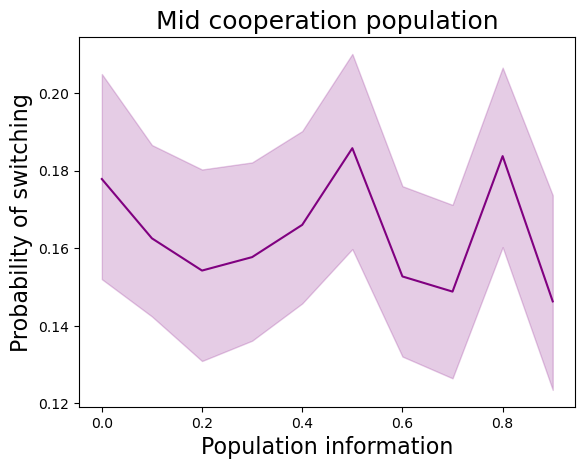

In [53]:
sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_ps', color="purple")
plt.xlabel("Population information", fontsize=16)
plt.ylabel("Probability of switching", fontsize=16)
plt.title("Mid cooperation population", fontsize=18)
plt.savefig(f"prob_switching-evolution-b{b_val}-a{a_val}.png")
plt.show()

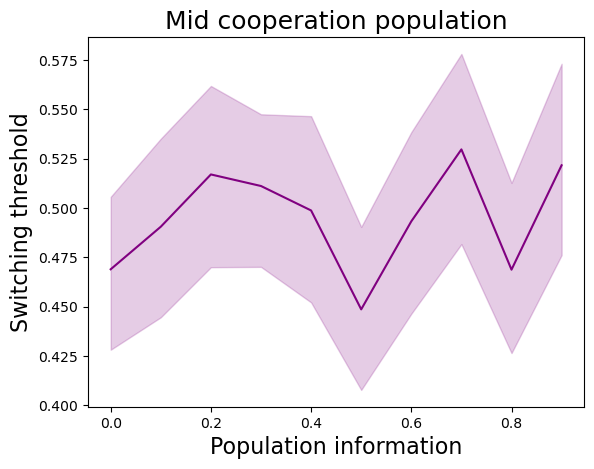

In [ ]:
sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_threshold', color="purple")
plt.xlabel("Population information", fontsize=16)
plt.ylabel("Switching threshold", fontsize=16)
plt.title("Mid cooperation population", fontsize=18)
plt.savefig(f"switching_threshold-evolution-b{b_val}-a{a_val}.png")
plt.show()

In [45]:
# # fig, ax = plt.subplots()

# # # First y-axis (left)
# # # sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_number_partners', color="teal", errorbar='sd', label="Total", ax=ax)
# # # sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_switched_from', color="coral", label="Switched from", ax=ax)

# # ax.set_xlabel('Population information', fontsize=18)
# # # ax.set_ylabel('Number of partners', fontsize=18)
# # ax.legend(loc='lower left', fontsize=14)

# # # ax.set_ylim(0, 20)
# # # ax.text(0, 57.5,'c)', fontsize=16)

# # # Second y-axis (right)
# # ax2 = ax.twinx()
# # sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_ps', color="purple", label="Probability of switching", ax=ax2)
# sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_ps', color="purple", label="Probability of switching")

# ax2.set_ylabel('Probability of switching', fontsize=18)
# ax2.legend(loc='lower right', fontsize=14)
# # ax2.set_ylim(0, 1)

# plt.title("Intermediate", fontsize=18)
# plt.tight_layout()
# # plt.savefig("adjusting_information-switching-line-midpop.png")
# plt.show()

In [46]:
# df_partner = df[df['mean_partner_pc'] != "NA"]

# sns.violinplot(x = df['run'], y = df['mean_pc'], data = df)
# plt.show()
# sns.violinplot(x = df['run'], y = df['mean_ps'], data = df)
# plt.show()
# sns.violinplot(x = df['pop_info'], y = df['mean_ps'], data = df)
# plt.show()

# regr = linear_model.LinearRegression()
# xpc = df_partner['mean_pc'].values
# yps = df_partner['mean_ps'].values
# krun = df_partner['run'].values
# xpc = xpc.reshape(len(xpc), 1)
# yps = yps.reshape(len(yps), 1)
# krun = krun.reshape(len(krun), 1)

# regr.fit(xpc, yps)

# sns.scatterplot(x = df_partner['mean_pc'], y = df_partner['mean_ps'], data = df_partner[df_partner['run']==run])
# plt.plot(xpc, regr.predict(xpc), color="purple")
# plt.show()
# sns.scatterplot(x = df_partner['mean_partner_pc'][df_partner['run']==run], y = df_partner['mean_ps'][df_partner['run']==run], data = df_partner[df_partner['run']==run])
# plt.show()

In [47]:
# all_mean_n_partners = []
# all_std_n_partners = []
# all_uncertainty = []
# all_mean_pc = []
# all_std_pc = []
# all_mean_ps = []
# all_pop_pc_dist = []
# all_iterations = []
# all_mean_payoff = []
# all_std_payoff = []
# all_mean_partner_pc = []
# all_std_partner_pc = []
# all_steps = []
# all_mean_switched_from = []
# all_rsquared_asstmnt = []
# all_coef_asstmnt = []
# all_rsquared_payoff = []
# all_coef_payoff = []

# pop_info = np.arange(0, 1, 0.01)

# all_ids = []
# all_switched_from = []
# all_mean_pc_indiv = []
# all_mean_ps_indiv = []
# run = []
# pop_infos = []
# all_mean_partner_pc_indiv = []
# a_val = 3
# b_val = 10
# num_iterations = 100
# num_timesteps = 1000
# for M in pop_info:
#     for j in np.arange(0, num_iterations):
#         population_size = 10
#         population = Population()

#         for id in range(population_size):
#             population.attach_animal(Animal(id, stats.beta.rvs(3, 10, size=1)[0]))

#         # ps_df = pd.DataFrame(columns=["animal_id", "ps_val", "pc_val"])
#         for i in range(num_timesteps):
#             animal = np.random.choice(population.animals)
#             animal.step(i)
#             # ps_df = pd.concat([ps_df, pd.DataFrame({"animal_id": [animal], "ps_val": [animal.ps], "pc_val": [animal.pc]})], ignore_index=True)

#         mean_n_partners = np.mean([animal.n_partners for animal in population.animals]) # calculate data means for the populations

#         run.append([j]* len(population.animals))
#         pop_infos.append([M] * len(population.animals))
#         all_ids.append([animal.id for animal in population.animals])
#         all_switched_from.append([animal.n_partners_switched_from for animal in population.animals])
#         all_mean_pc_indiv.append([animal.pc for animal in population.animals])
#         all_mean_ps_indiv.append([animal.ps for animal in population.animals])
#         for animal in population.animals:
#             if animal.partner is not None:
#                 all_mean_partner_pc_indiv.append(animal.partner.pc)
#             else:
#                 all_mean_partner_pc_indiv.append('NA')

#         mean_n_switched_from = np.mean([animal.n_partners_switched_from for animal in population.animals])
#         mean_pc = np.mean([animal.pc for animal in population.animals])
#         std_pc = np.std([animal.pc for animal in population.animals])
#         mean_ps = np.mean([animal.ps for animal in population.animals])
#         mean_partner_pc = np.mean([animal.partner.pc for animal in population.animals if animal.partner is not None])
#         std_partner_pc = np.std([animal.partner.pc for animal in population.animals if animal.partner is not None])

#         all_mean_n_partners.append(mean_n_partners) # add data to lists
#         all_mean_switched_from.append(mean_n_switched_from)
#         all_mean_pc.append(mean_pc)
#         all_mean_ps.append(mean_ps)
#         all_uncertainty.append(M)
#         all_iterations.append(j)
#         all_mean_partner_pc.append(mean_partner_pc)

# df_agg = pd.DataFrame({'iteration': all_iterations, 'all_uncertainty': all_uncertainty, 'mean_number_partners': all_mean_n_partners, 'mean_pc': all_mean_pc, 'mean_partner_pc': all_mean_partner_pc, 'mean_switched_from': all_mean_switched_from, 'mean_ps': all_mean_ps})

# df = pd.DataFrame({
#     "run": np.array(run).flatten(),
#     "pop_info": np.array(pop_infos).flatten(),
#     "individual_id": np.array(all_ids).flatten(),
#     "switched_from": np.array(all_switched_from).flatten(),
#     "mean_pc": np.array(all_mean_pc_indiv).flatten(),
#     "mean_ps": np.array(all_mean_ps_indiv).flatten(),
#     "mean_partner_pc": np.array(all_mean_partner_pc_indiv).flatten()
# })

# df.to_csv(f"adjusting_a{a_val}-b{b_val}.csv")
# df_agg.to_csv(f"adjusting_agg_a{a_val}-b{b_val}.csv")

In [48]:
# ## ADD LETTERS TO FIGURES!!
# fig, ax = plt.subplots()

# # First y-axis (left)
# sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_number_partners', color="teal", errorbar='sd', label="Total", ax=ax)
# # sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_switched_from', color="coral", label="Switched from", ax=ax)

# ax.set_xlabel('Population information', fontsize=18)
# ax.set_ylabel('Number of partners', fontsize=18)
# ax.legend(loc='upper left', fontsize=14)

# # ax.set_ylim(0, 20)
# ax.text(0, 55,'a)', fontsize=16)

# # Second y-axis (right)
# ax2 = ax.twinx()
# sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_ps', color="purple", label="Probability of switching", ax=ax2)

# ax2.set_ylabel('Probability of switching', fontsize=18)
# # ax2.legend(loc='upper right', fontsize=14)
# ax2.set_ylim(0, 1)

# plt.title("Low", fontsize=18)
# plt.tight_layout()
# # plt.savefig("adjusting_information-switching-line-uncooppop.png")
# plt.show()

In [49]:
# df_partner = df[df['mean_partner_pc'] != "NA"]

# sns.violinplot(x = df['run'], y = df['mean_pc'], data = df)
# plt.show()
# sns.violinplot(x = df['run'], y = df['mean_ps'], data = df)
# plt.show()
# sns.violinplot(x = df['pop_info'], y = df['mean_ps'], data = df)
# plt.show()

# regr = linear_model.LinearRegression()
# xpc = df_partner['mean_pc'].values
# yps = df_partner['mean_ps'].values
# krun = df_partner['run'].values
# xpc = xpc.reshape(len(xpc), 1)
# yps = yps.reshape(len(yps), 1)
# krun = krun.reshape(len(krun), 1)

# regr.fit(xpc, yps)

# sns.scatterplot(x = df_partner['mean_pc'], y = df_partner['mean_ps'], data = df_partner[df_partner['run']==run])
# plt.plot(xpc, regr.predict(xpc), color="purple")
# plt.show()
# sns.scatterplot(x = df_partner['mean_partner_pc'][df_partner['run']==run], y = df_partner['mean_ps'][df_partner['run']==run], data = df_partner[df_partner['run']==run])
# plt.show()

In [50]:
# all_mean_n_partners = []
# all_std_n_partners = []
# all_uncertainty = []
# all_mean_pc = []
# all_std_pc = []
# all_mean_ps = []
# all_pop_pc_dist = []
# all_iterations = []
# all_mean_payoff = []
# all_std_payoff = []
# all_mean_partner_pc = []
# all_std_partner_pc = []
# all_steps = []
# all_mean_switched_from = []
# all_rsquared_asstmnt = []
# all_coef_asstmnt = []
# all_rsquared_payoff = []
# all_coef_payoff = []

# pop_info = np.arange(0, 1, 0.01)

# all_ids = []
# all_switched_from = []
# all_mean_pc_indiv = []
# all_mean_ps_indiv = []
# run = []
# pop_infos = []
# all_mean_partner_pc_indiv = []
# a_val = 10
# b_val = 3
# num_iterations = 100
# num_timesteps = 1000

# for M in pop_info:
#     for j in np.arange(0, num_iterations):
#         population_size = 10
#         population = Population()

#         for id in range(population_size):
#             population.attach_animal(Animal(id, stats.beta.rvs(10, 3, size=1)[0]))

#         # ps_df = pd.DataFrame(columns=["animal_id", "ps_val", "pc_val"])
#         for i in range(num_timesteps):
#             animal = np.random.choice(population.animals)
#             animal.step(i)
#             # ps_df = pd.concat([ps_df, pd.DataFrame({"animal_id": [animal], "ps_val": [animal.ps], "pc_val": [animal.pc]})], ignore_index=True)

#         mean_n_partners = np.mean([animal.n_partners for animal in population.animals]) # calculate data means for the populations

#         run.append([j]* len(population.animals))
#         pop_infos.append([M] * len(population.animals))
#         all_ids.append([animal.id for animal in population.animals])
#         all_switched_from.append([animal.n_partners_switched_from for animal in population.animals])
#         all_mean_pc_indiv.append([animal.pc for animal in population.animals])
#         all_mean_ps_indiv.append([animal.ps for animal in population.animals])
#         for animal in population.animals:
#             if animal.partner is not None:
#                 all_mean_partner_pc_indiv.append(animal.partner.pc)
#             else:
#                 all_mean_partner_pc_indiv.append('NA')

#         mean_n_switched_from = np.mean([animal.n_partners_switched_from for animal in population.animals])
#         mean_pc = np.mean([animal.pc for animal in population.animals])
#         std_pc = np.std([animal.pc for animal in population.animals])
#         mean_ps = np.mean([animal.ps for animal in population.animals])
#         mean_partner_pc = np.mean([animal.partner.pc for animal in population.animals if animal.partner is not None])
#         std_partner_pc = np.std([animal.partner.pc for animal in population.animals if animal.partner is not None])

#         all_mean_n_partners.append(mean_n_partners) # add data to lists
#         all_mean_switched_from.append(mean_n_switched_from)
#         all_mean_pc.append(mean_pc)
#         all_mean_ps.append(mean_ps)
#         all_uncertainty.append(M)
#         all_iterations.append(j)
#         all_mean_partner_pc.append(mean_partner_pc)

# df_agg = pd.DataFrame({'iteration': all_iterations, 'all_uncertainty': all_uncertainty, 'mean_number_partners': all_mean_n_partners, 'mean_pc': all_mean_pc, 'mean_partner_pc': all_mean_partner_pc, 'mean_switched_from': all_mean_switched_from, 'mean_ps': all_mean_ps})

# df = pd.DataFrame({
#     "run": np.array(run).flatten(),
#     "pop_info": np.array(pop_infos).flatten(),
#     "individual_id": np.array(all_ids).flatten(),
#     "switched_from": np.array(all_switched_from).flatten(),
#     "mean_pc": np.array(all_mean_pc_indiv).flatten(),
#     "mean_ps": np.array(all_mean_ps_indiv).flatten(),
#     "mean_partner_pc": np.array(all_mean_partner_pc_indiv).flatten()
# })

# df.to_csv(f"adjusting_a{a_val}-b{b_val}.csv")
# df_agg.to_csv(f"adjusting_agg_a{a_val}-b{b_val}.csv")

In [51]:
# ## ADD LETTERS TO FIGURES!!
# fig, ax = plt.subplots()

# # First y-axis (left)
# sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_number_partners', color="teal", errorbar='sd', label="Total", ax=ax)
# # sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_switched_from', color="coral", label="Switched from", ax=ax)

# ax.set_xlabel('Population information', fontsize=18)
# ax.set_ylabel('Number of partners', fontsize=18)
# ax.legend(loc='lower left', fontsize=14)

# # ax.set_ylim(0, 20)
# ax.text(0, 56.5,'b)', fontsize=16)

# # Second y-axis (right)
# ax2 = ax.twinx()
# sns.lineplot(data=df_agg, x='all_uncertainty', y='mean_ps', color="purple", label="Probability of switching", ax=ax2)

# ax2.set_ylabel('Probability of switching', fontsize=18)
# ax2.legend(loc='lower right', fontsize=14)
# ax2.set_ylim(0, 1)

# plt.title("High", fontsize=18)
# plt.tight_layout()
# # plt.savefig("adjusting_information-switching-line-cooppop.png")
# plt.show()

In [52]:
# df_partner = df[df['mean_partner_pc'] != "NA"]

# sns.violinplot(x = df['run'], y = df['mean_pc'], data = df)
# plt.show()
# sns.violinplot(x = df['run'], y = df['mean_ps'], data = df)
# plt.show()
# sns.violinplot(x = df['pop_info'], y = df['mean_ps'], data = df)
# plt.show()

# regr = linear_model.LinearRegression()
# xpc = df_partner['mean_pc'].values
# yps = df_partner['mean_ps'].values
# krun = df_partner['run'].values
# xpc = xpc.reshape(len(xpc), 1)
# yps = yps.reshape(len(yps), 1)
# krun = krun.reshape(len(krun), 1)

# regr.fit(xpc, yps)

# sns.scatterplot(x = df_partner['mean_pc'], y = df_partner['mean_ps'], data = df_partner[df_partner['run']==run])
# plt.plot(xpc, regr.predict(xpc), color="purple")
# plt.show()
# sns.scatterplot(x = df_partner['mean_partner_pc'][df_partner['run']==run], y = df_partner['mean_ps'][df_partner['run']==run], data = df_partner[df_partner['run']==run])
# plt.show()